In [1]:
import numpy as np
import matplotlib.pyplot as plt

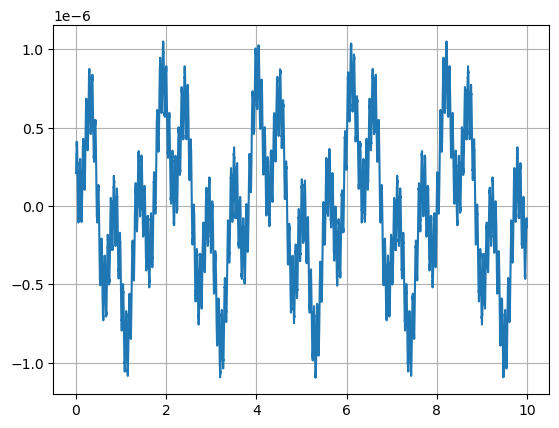

In [8]:
# define a simple 1 DoF system
amps = np.array([0.5,0.4,0.02,0.2])*1e-6
freqs = np.array([3,12,740,92])
phases = np.array([0,125,69,250])

dt = 1e-4
tvec = np.arange(1e+5)*dt

plant = lambda t: amps[0]*np.cos(t*freqs[0]+phases[0]/180*np.pi) + amps[1]*np.cos(t*freqs[1]+phases[1]/180*np.pi) + amps[2]*np.cos(t*freqs[2]+phases[2]/180*np.pi) + amps[3]*np.cos(t*freqs[3]+phases[3]/180*np.pi)
y = plant(tvec)

plt.figure()
plt.plot(tvec,y)
plt.grid()

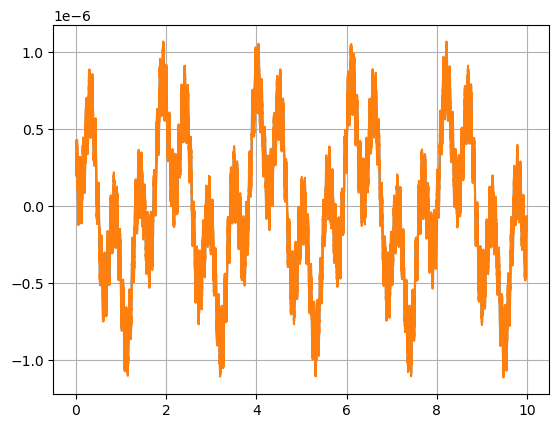

In [13]:
# simple controller with noise and n-steps delay
sigma = 1e-8
y_meas = y + np.random.randn(len(y))*sigma

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,y_meas)
plt.grid()

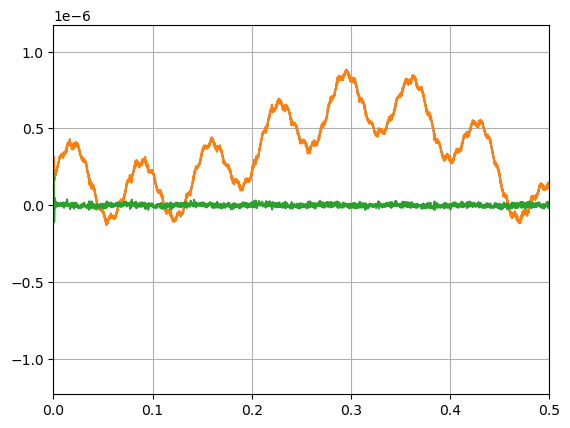

In [26]:
# actuator with n steps delay
N = len(y)
cmd_hist = np.zeros(N)
cmd = 0
int_gain = 0.4
delay_steps = 3

for j in range(N):
    if j >= delay_steps:
        meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn(1)*sigma
    else:
        meas = y[j] + np.random.randn(1)*sigma
    cmd += int_gain*meas[0]
    cmd_hist[j] = cmd

res = y.copy()
res[delay_steps:] -= cmd_hist[:-delay_steps]

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,cmd_hist)
plt.plot(tvec,res)
plt.xlim([0,0.5])
plt.grid()

In [60]:
# Predictor controller, M = 1, N = 4
Mf = 3 # future steps
Np = 4 # past states
theta = np.zeros(Mf*(2*Np + Mf)) # parameters
P = np.eye(len(theta))*1e+9

gamma = 1.0 # forgetting factor
lreg = 1e-3

In [61]:
A = theta[:Np]
B = theta[Np:2*Np]
C = theta[2*Np:]
CMAT = lambda A,B,C,lreg: -np.linalg.pinv(C.T @ C + lreg*np.eye(len(C))) * np.concatenate([A.T @ C, B.T @ C])

In [62]:
def ddspc_step(y,phi,theta,P,gamma=1.0,lreg=1e-3):
    K = P @ phi / (gamma + phi.T @ P @ phi)
    err = y - phi.T @ theta
    theta += K * err
    P = 1/gamma * (P - np.outer(K, phi) @ P)

    A = theta[:Np]
    B = theta[Np:2*Np]
    C = theta[2*Np:]
    Cmat = CMAT(A,B,C,lreg)
    cmd = Cmat @ phi[:2*Np]
    return cmd, theta, P, K

In [63]:
# Run DDSPC controller
past_y = np.zeros(Np)
past_u = np.zeros(Np)
cmd_hist = np.zeros(len(y))
for j in range(len(y)):
    phi_full = np.concatenate([past_y, past_u, np.zeros(Mf)])
    cmd, theta, P, _ = ddspc_step(0, phi_full, theta, P)  # initial cmd
    cmd_hist[j] = cmd
    if j >= delay_steps:
        meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn()*sigma
    else:
        meas = y[j] + np.random.randn()*sigma
    # update past
    past_y = np.roll(past_y, -1)
    past_y[-1] = meas
    past_u = np.roll(past_u, -1)
    past_u[-1] = cmd
    # update the model with the meas
    phi_update = np.concatenate([past_y, past_u, [cmd]])
    _, theta, P, _ = ddspc_step(meas, phi_update, theta, P)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 11 is different from 33)

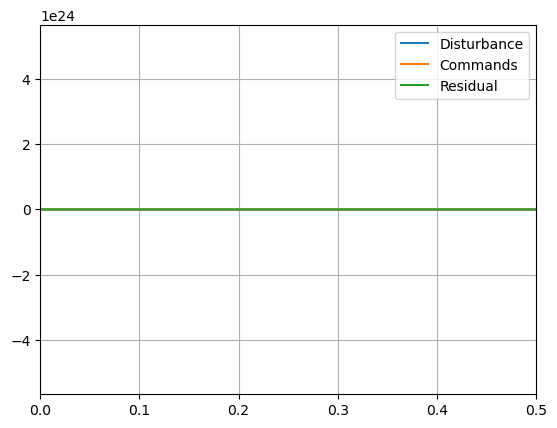

In [ ]:
res = y.copy()
res[delay_steps:] -= cmd_hist[:-delay_steps]

plt.figure()
plt.plot(tvec,y, label='Disturbance')
plt.plot(tvec,cmd_hist, label='Commands')
plt.plot(tvec,res, label='Residual')
plt.xlim([0,0.5])
plt.legend()
plt.grid()